# Usage

## Installing Dependencies

If we are in Colab, we start by installing some dependencies. If not, please follow [the installation instructions](https://hri-eu.github.io/ProMis/installation.html).

In [1]:
def is_running_in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if is_running_in_colab():
  !sudo apt-get update -qq
  !sudo apt-get install -yqq python3-gdal libgdal-dev
  !pip install -q promis


## Imports

Next, we import some of ProMis' core packages and third party dependencies.

In [2]:
# Python Standard Library
from pathlib import Path

# Probabilistic Mission Design and Statistical Relational Maps
from promis import ProMis, StaRMap
# Geographic data handling
from promis.geo import PolarLocation, CartesianMap, CartesianLocation, CartesianRasterBand, CartesianCollection
# Data loading from a local OpenStreetMap file
from promis.loaders import LocalOsmLoader

# Third Party dependencies we will need
from numpy import eye
import matplotlib.pyplot as plt
from os.path import exists

In [3]:
# The directory will later hold various files, like the StaRMap
Path("data").mkdir(exist_ok=True)

## Uncertainty Annotated Maps

Probabilistic missions are built on an uncertainty aware environment representation we call Uncertainty Annotated Maps (UAM).
Here, to obtain a UAM, we query crowd-sourced data from OpenStreetMap (OSM) using ProMis' OsmLoader class.
The OsmLoader expects a feature description consisting of a location type that identifies the respective set of features and a 'filter' describing the OSM tags and their values to be selected.

In [4]:
# The features we will load from OpenStreetMap
# The dictionary key will be stored as the respective features location_type
# The dictionary value is an Overpass-style filter selecting the relevant geometry
feature_description = {
    "park": "[leisure=park]",
    "primary": "[highway=primary]",
    "secondary": "[highway=secondary]",
    "tertiary": "[highway=tertiary]",
    "service": "[highway=service]",
    "crossing": "[footway=crossing]",
    "bay": "[natural=bay]",
    "rail": "[railway=rail]",
}

Since we do not know how noisy the OSM data actually is, we define some noise ourselves for demonstration purposes.
In an actual application, you would insert your (neural) sensors and mapping modules' accuracy information here.

Here, the environment features will be assumed to be placed where we expect them with a random translation sampled from a Gaussian with one of the following covariance matrices.

In [5]:
# Covariance matrices for some of the features
# Used to draw random translations representing uncertainty for the respective features
covariance = {
    "primary": 15 * eye(2),
    "secondary": 10 * eye(2),
    "tertiary": 5 * eye(2),
    "service": 2.5 * eye(2),
    "operator": 20 * eye(2),
}

As a last piece of information before the UAM can be queried, we need to define the area in which our agent's mission will take place in.

In [4]:
# The mission area's origin in polar coordinates as well as area extends in meters
origin = PolarLocation(latitude=49.878091, longitude=8.654052)
width, height = 1000.0, 1000.0

Finally, we can load the relevant environment features from the local OSM file.
We also apply our uncertainties in the data, place the position of the agent's operator at the center of the mission area, and store the resulting UAM to disk.

In [7]:
# Setting up the Uncertainty Annotated Map from a local OSM file
uam = LocalOsmLoader("data/Darmstadt.osm.pbf", origin, (width, height), feature_description).to_cartesian_map()

# Adding the operator's location and applying out assumed levels of uncertainty
uam.features.append(CartesianLocation(0.0, 0.0, location_type="operator"))
uam.apply_covariance(covariance)

# We store the UAM to disk for later usage
uam.save(f"data/uam.pkl")

Loading park with filter [leisure=park]
Loading primary with filter [highway=primary]
Loading secondary with filter [highway=secondary]
Loading tertiary with filter [highway=tertiary]
Loading service with filter [highway=service]
Loading crossing with filter [footway=crossing]
Loading bay with filter [natural=bay]
Loading rail with filter [railway=rail]


Now its time to consider what our actual mission requirements are and express them as a Resin program.

Resin is a reactive probabilistic logic language where rules are written over spatial relation *sources*.
Each source declares a relation (e.g. `distance`, `over`) and a location type, along with whether it carries a bare `Probability` or a continuous `Density` (for which Resin evaluates the CDF at any threshold used in rule bodies).

Rules use `if` for disjunctive clauses and `and` for conjunction.
A final `-> target(...)` declaration names the output we want to query.
Comments start with `#`.

In [5]:
resin_program = """
# Spatial relation sources
over(park) <- source("/star_map/over/park", Probability).
over(bay) <- source("/star_map/over/bay", Probability).
distance(operator) <- source("/star_map/distance/operator", Density).
distance(service) <- source("/star_map/distance/service", Density).
distance(primary) <- source("/star_map/distance/primary", Density).
distance(secondary) <- source("/star_map/distance/secondary", Density).
distance(tertiary) <- source("/star_map/distance/tertiary", Density).
distance(rail) <- source("/star_map/distance/rail", Density).
distance(crossing) <- source("/star_map/distance/crossing", Density).

# Visual line of sight: within the operator's range, or over a bay at extended range
vlos if distance(operator) < 500.0.
vlos if over(bay) and distance(operator) < 400.0.

# Permits based on proximity to infrastructure or green space
permits if over(park).
permits if distance(service) < 15.0.
permits if distance(primary) < 15.0.
permits if distance(secondary) < 10.0.
permits if distance(tertiary) < 5.0.
permits if distance(rail) < 5.0.
permits if distance(crossing) < 5.0.

# A valid mission requires line of sight and local permits
landscape if vlos and permits.
landscape -> target("/landscape").
"""

Now its time to compute the StaR Map.
For this, we load the UAM from disk, define some points in the mission area to compute the StaR Map for and initialize it for the rules we defined above.

In [9]:
# Setting up the probabilistic spatial relations from the UAM we previously computed
star_map = StaRMap(CartesianMap.load(f"data/uam.pkl"))

# Initializing the StaR Map on a raster of points evenly spaced out across the mission area,
# sampling 25 random variants of the UAM for estimating the spatial relation parameters.
# The Resin program determines which relations are needed.
evaluation_points = CartesianRasterBand(origin, (15, 15), width, height)
star_map.initialize(evaluation_points, number_of_random_maps=25, logic=resin_program)

# We store the StaR Map to disk
star_map.save(f"data/star_map.pkl")

Let's inspect the parameters of the StaR Map relations by visualizing the estimated values.
We do so by accessing the parameters (a `promis.geo.Collection` holding mean and variances for each sampled point), and interpolating to a more fine-granular grid over the mission area.

In [6]:
# Visualize the spatial relations with an OSM basemap in the background
def show_collection(collection, value_index, ax, title):
    # Fine-granular interpolation target for the spatial relations
    mission_area = CartesianRasterBand(collection.origin, (300, 300), width, height)

    image = collection.into(mission_area).scatter(value_index=value_index, ax=ax, s=0.4, plot_basemap=True, rasterized=True, cmap="coolwarm_r", alpha=0.25)
    cbar = plt.colorbar(image, aspect=18.5, fraction=0.05, pad=0.02)
    cbar.solids.set(alpha=1)
    ax.set_title(title)

def set_style(axes=None):
    if axes is None:
        axes = plt.gcf().axes
    # Set axes labeling
    ticks = [-width / 2.0, 0, width / 2.0]
    labels = ["0", "0.5", "1"]
    axes[0].set_ylabel("Northing / km")
    axes[0].set_yticks(ticks, labels)
    axes[0].set_ylim([-height / 2.0, height / 2.0])
    for ax in axes:
        ax.set_xlabel("Easting / km")
        ax.set_xticks(ticks, labels)
        ax.set_xlim([-width / 2.0, width / 2.0])

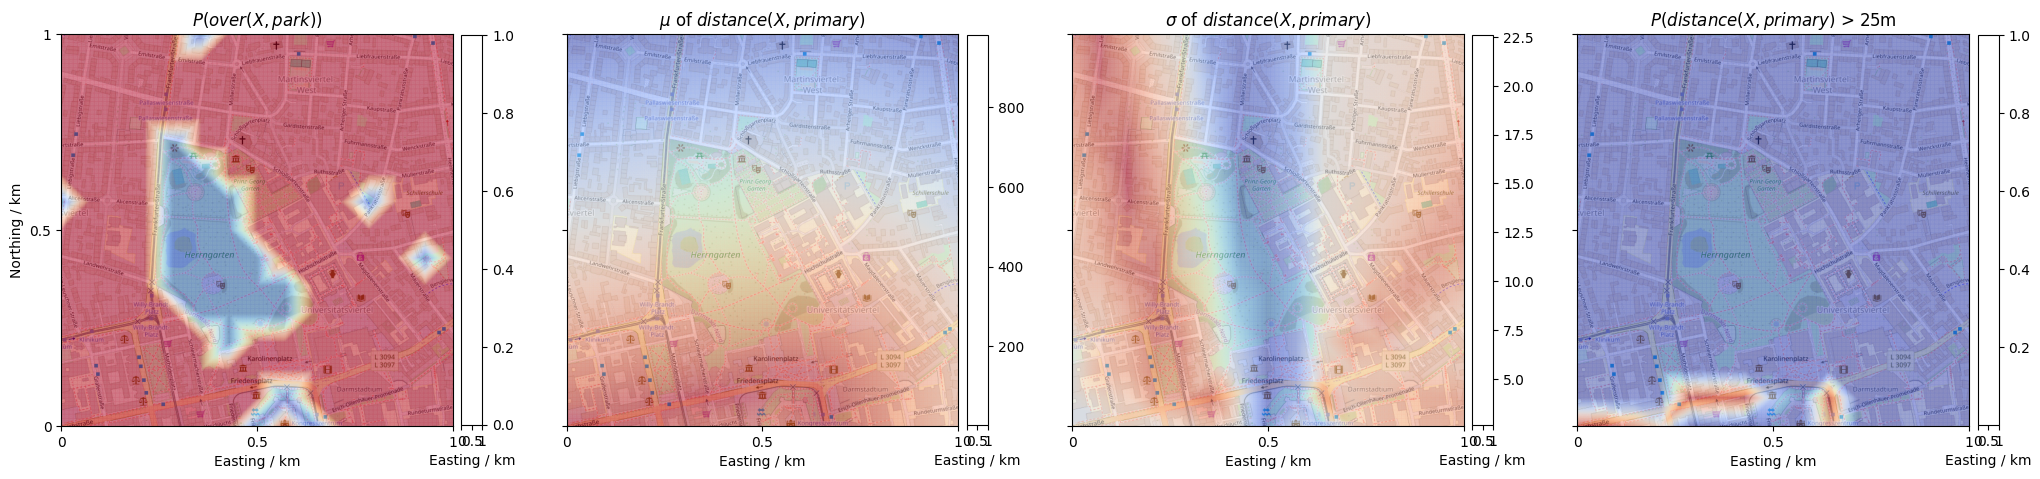

In [11]:
# Load the StaR Map data and prepare the figure
star_map = StaRMap.load(f"data/star_map.pkl")
fig, axes = plt.subplots(1, 4, sharey=True, figsize=(25, 10))

# We can query each relation from the StaR Map given its name and the location type it relates to
over_park = star_map.get("over", "park")
distance_primary = star_map.get("distance", "primary")

show_collection(over_park.parameters, 0, axes[0], r'$P(over(X, park))$')
show_collection(distance_primary.parameters, 0, axes[1], r'$\mu$ of $distance(X, primary)$')
show_collection(distance_primary.parameters, 1, axes[2], r'$\sigma$ of $distance(X, primary)$')
show_collection(distance_primary > 25, 0, axes[3], r'$P(distance(X, primary)$ > 25m')

# Show results
set_style()
plt.show()

While this already allows us some reasoning with ProMis on what the agent may or may not be allowed to do, we should improve the spatial resolution of our relations before continuing.
We can do so by applying StaR Maps adaptive sampling functionality, which will sample each relation based on an acquisition function.
Currently, local entropy and Gaussian Process uncertainty together with a distance based score are provided.

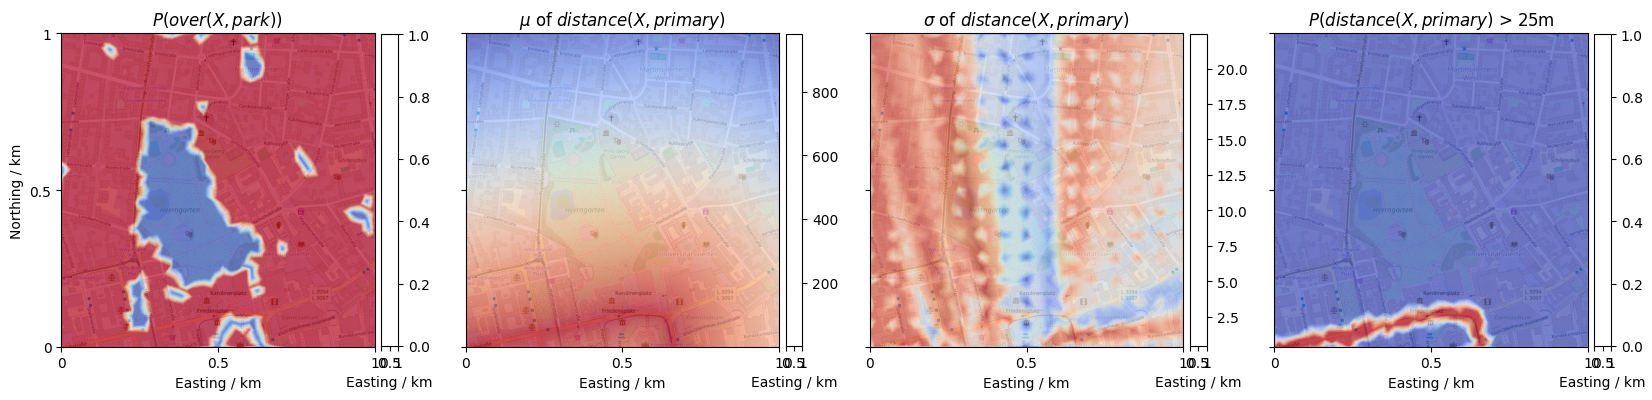

In [12]:
# Load the StaR Map data and run an auto-improvement, store the improved one
star_map = StaRMap.load(f"data/star_map.pkl")
star_map.adaptive_sample(
    candidate_sampler=lambda: CartesianCollection.make_latin_hypercube(origin, width, height, number_of_samples=1000, include_corners=True),
    number_of_random_maps=5,
    number_of_iterations=15,
    number_of_improvement_points=100,
    acquisition_method = "gaussian_process"
)
star_map.save(f"data/improved_star_map.pkl")

# Show the improved spatial relations
fig, axes = plt.subplots(1, 4, sharey=True, figsize=(20, 7.5))

# We can query each relation from the StaR Map given its name and the location type it relates to
over_park = star_map.get("over", "park")
distance_primary = star_map.get("distance", "primary")

show_collection(over_park.parameters, 0, axes[0], r'$P(over(X, park))$')
show_collection(distance_primary.parameters, 0, axes[1], r'$\mu$ of $distance(X, primary)$')
show_collection(distance_primary.parameters, 1, axes[2], r'$\sigma$ of $distance(X, primary)$')
show_collection(distance_primary > 25, 0, axes[3], r'$P(distance(X, primary)$ > 25m')

# Show results
set_style()
plt.show()

## Probabilistic Mission Design

We can now employ ProMis' core functionality: computing a Probabilistic Mission Landscape (PML).
A PML is a scalar field expressing at each point in the agent's state space how probable it is that all stated rules are satisfied.

`ProMis` takes the StaRMap, the Resin program, and the number of evaluation points.
Calling `initialize` writes all map-derived relation parameters into the reactive circuit, and `update` runs inference to produce the landscape.

In [ ]:
# Evaluation raster for the mission landscape
resolution = (1000, 1000)
raster = CartesianRasterBand(origin, resolution, width, height)
dimension = resolution[0] * resolution[1]

# Compile the Resin program, wire StaRMap sources, and run inference
promis = ProMis(StaRMap.load(f"data/improved_star_map.pkl"), resin_program, dimension)
promis.initialize(raster)
landscape = promis.update()

landscape.save(f"data/landscape.pkl")

Compiling Resin from program:

# Spatial relation sources
over(park) <- source("/star_map/over/park", Probability).
over(bay) <- source("/star_map/over/bay", Probability).
distance(operator) <- source("/star_map/distance/operator", Density).
distance(service) <- source("/star_map/distance/service", Density).
distance(primary) <- source("/star_map/distance/primary", Density).
distance(secondary) <- source("/star_map/distance/secondary", Density).
distance(tertiary) <- source("/star_map/distance/tertiary", Density).
distance(rail) <- source("/star_map/distance/rail", Density).
distance(crossing) <- source("/star_map/distance/crossing", Density).

# Visual line of sight: within the operator's range, or over a bay at extended range
vlos if distance(operator) < 500.0.
vlos if over(bay) and distance(operator) < 400.0.

# Permits based on proximity to infrastructure or green space
permits if over(park).
permits if distance(service) < 15.0.
permits if distance(primary) < 15.0.
permits if dista

Let's inspect the resulting landscape!
Blue regions indicate high probability of satisfying all constraints, and red areas should be avoided.

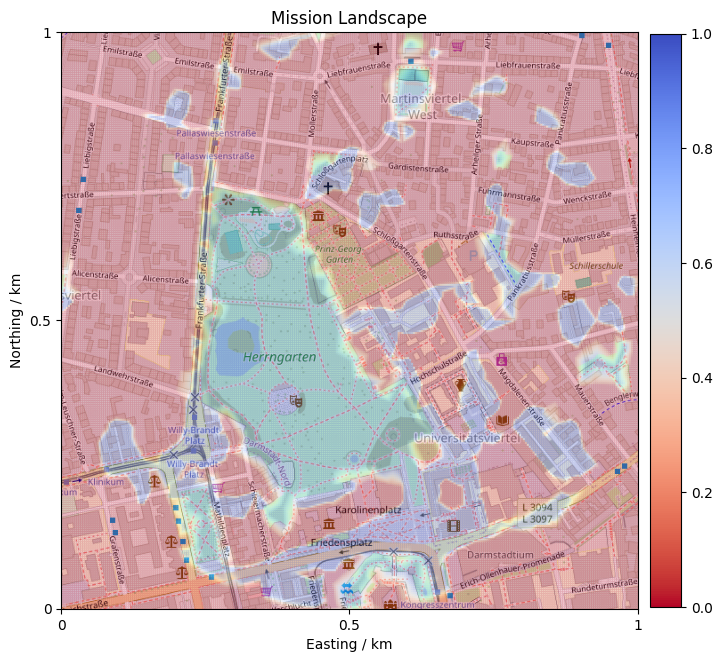

In [ ]:
# Show the Probabilistic Mission Landscape
fig, ax = plt.subplots(1, 1, figsize=(8, 7.5))

show_collection(CartesianRasterBand.load("data/landscape.pkl"), 0, ax, r'Mission Landscape')

set_style([ax])
plt.show()